# Figure 6 - Brief analysis of Transcription Factor binding Sites

## Goals:
1. Characterize cell cycle nature of cycling transcription factors, prevelence of PTR
2. Characterize which of these are associated with genes and whether those genes are cell cycle (cross-reference with transcription-story)


In [18]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [430]:
from src.TranscriptionFactorProcessor import TranscriptionFactorProcessor

# Initialize and run comprehensive analysis
analyzer = TranscriptionFactorProcessor(output_dir='output/draft4_run/')
full_results = analyzer.build_comprehensive_dataframe(include_ptr=True)

# Access different aspects
gene_associations = full_results['associated_genes']  # "CLB5,THI22" format
ptr_values = full_results[['ptr']]
association_stats = analyzer.get_association_summary()


Building comprehensive dataframe with gene associations...
Loading TF binding datasets...
Number of total factors profiled by Rossi:  319
Number of TFs selected by GO terms (GO:0016563,GO:0043565):  166
Number of TFs with Rossi binding sites:  76
   of these, Kelliher cell-cycle TFS:  12
Found 2793 high-confidence binding sites for 76 cell cycle TFs
Preparing binding site coordinates...
Prepared 2793 binding sites with ±40bp windows
Loading and processing chromatin data...
Processing site 1/2793
Processing site 51/2793
Processing site 101/2793
Processing site 151/2793
Processing site 201/2793
Processing site 251/2793
Processing site 301/2793
Processing site 351/2793
Processing site 401/2793
Processing site 451/2793
Processing site 501/2793
Processing site 551/2793
Processing site 601/2793
Processing site 651/2793
Processing site 701/2793
Processing site 751/2793
Processing site 801/2793
Processing site 851/2793
Processing site 901/2793
Processing site 951/2793
Processing site 1001/2793

Number of transcription factors with >20 sites 28


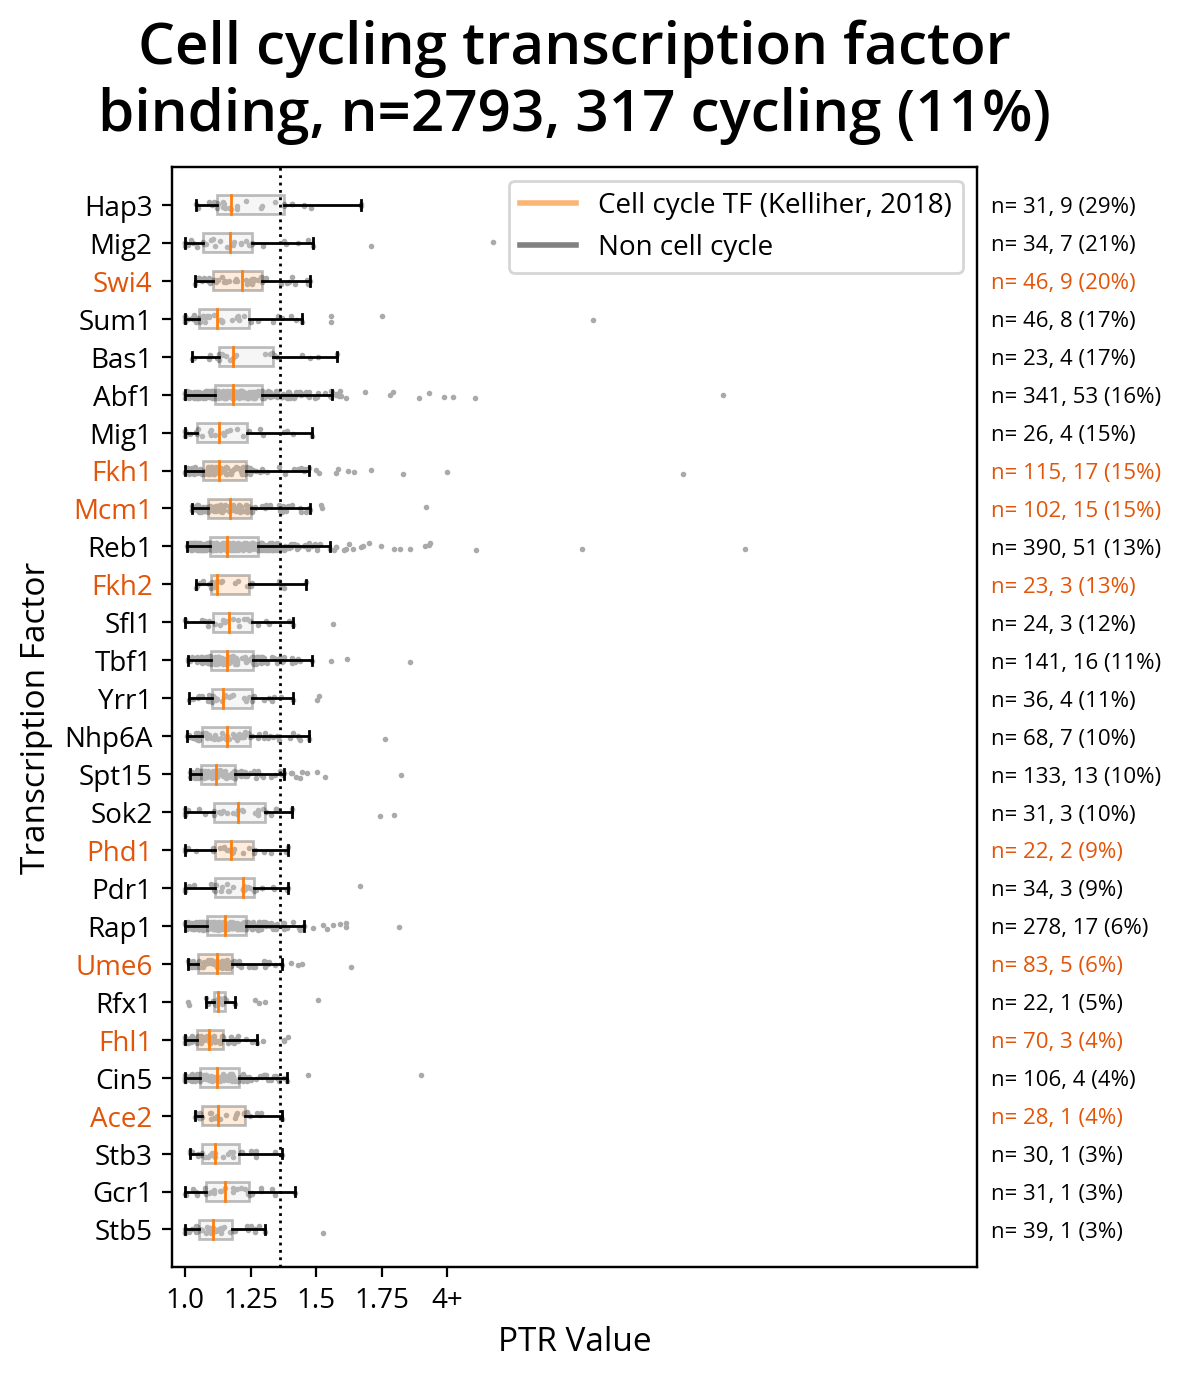

In [565]:
fig, ax, plotted_tfs = analyzer.plot_tf_boxplots()

In [529]:
from src.transcripts_dataset import load_transcripts_sets

def classify_site_with_genes(site, gene_boundaries):
    # Check if the site is within a gene's body: TSS-PAS

    # Check if the site is within a promoter: predefined promoter range
    chrom_strand_check = (site.chr == gene_boundaries.chr) & \
                    (site.strand == gene_boundaries.strand)

    found_in_genes = gene_boundaries[chrom_strand_check & 
                    (site.end > gene_boundaries.full_transcript_start) &
                    (site.start < gene_boundaries.full_transcript_end)]

    found_in_promoter = gene_boundaries[chrom_strand_check & 
                    (site.end > gene_boundaries.promoter_start) &
                    (site.start < gene_boundaries.promoter_end)]

    if len(found_in_genes) > 0:
        classification = 'gene_body'
    elif len(found_in_promoter) > 0:
        classification = 'promoter'
    else:
        classification = 'intergenic'
    return classification

In [570]:
gene_boundaries, _  = load_transcripts_sets(analyzer.output_dir)
ptrs = analyzer.comprehensive_df[['ptr']].dropna()
cell_cycle_sites = ptrs[ptrs.ptr > analyzer.ptr_threshold]

# Next we'll look through these sites and count the occurrence in various gene contexts
tf_sites = analyzer.tf_sites.copy()
tf_sites.index.name = 'identifier'
tf_sites = tf_sites.reset_index().set_index(["tf", 'identifier'])
cell_cycle_sites_with_peaks = cell_cycle_sites.join(tf_sites, how='left').loc[plotted_tfs]

In [571]:
for site_index, site in cell_cycle_sites_with_peaks.iterrows():
    classification = classify_site_with_genes(site, gene_boundaries)
    cell_cycle_sites_with_peaks.loc[site_index, 'genomic_classification'] = classification


In [577]:
# Group by both TF and classification
counts = cell_cycle_sites_with_peaks.groupby(['tf', 'genomic_classification']).size().reset_index(name='count')

# Pivot for easier viewing
pivot_counts = counts.pivot(index='tf', columns='genomic_classification', values='count').fillna(0)\
    .loc[plotted_tfs]

AttributeError: Rectangle.set() got an unexpected keyword argument 'labels'

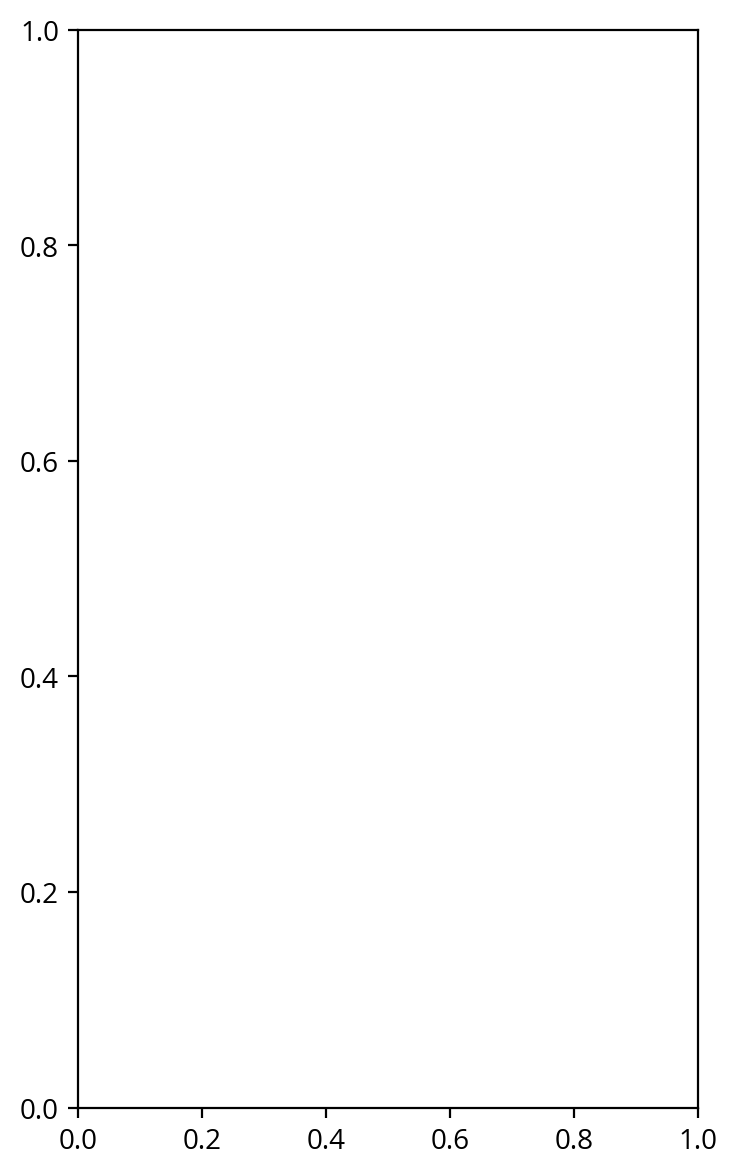

In [593]:
import matplotlib.pyplot as plt

# Assuming your pivot table is called 'pivot_counts'
fig, ax = plt.subplots(figsize=(4, 7))

# Plot with specific column order
pivot_counts[['promoter', 'gene_body', 'intergenic']].plot(kind='barh', stacked=True, ax=ax,
    color=[plt.cm.Oranges(0.5), plt.cm.Purples(0.6), '#aaa'],                                                        
    labels=['Promoter', 'Gene Body', 'Intergenic'])

# Customize the plot
plt.xlabel('Number of Sites')
plt.ylabel('Transcription Factor')
plt.title('Location of Cycling TF sites', 
    fontweight='demi', fontsize=18, pad=13)
plt.legend(title='Classification', loc='lower right')


In [574]:
len(pivot_counts)

28